In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.append(os.path.abspath("..")) 
from prokaryotic.functional import categorize_functional_shifts

ORGANISMS = {
    "bacillus": "B. subtilis",
    "e_coli": "E. coli"
}
TOOLS_TO_EVALUATE = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']

COLOR_MAP = {
    'Both Informative': '#66c2a5', 
    'Both Hypothetical': '#fc8d62', 
    'Over-Annotation': '#8da0cb',  
    'Under-Annotation': '#e78ac3'    
}


  Evaluating Functional Data: B. subtilis



Category,Both Informative,Both Hypothetical,Over-Annotation,Under-Annotation
Tool,,,,
Bakta,2044,1481,306,409
PGAP,2396,563,1224,57
Prokka,1821,1455,332,632
eggNOG,2122,818,969,331


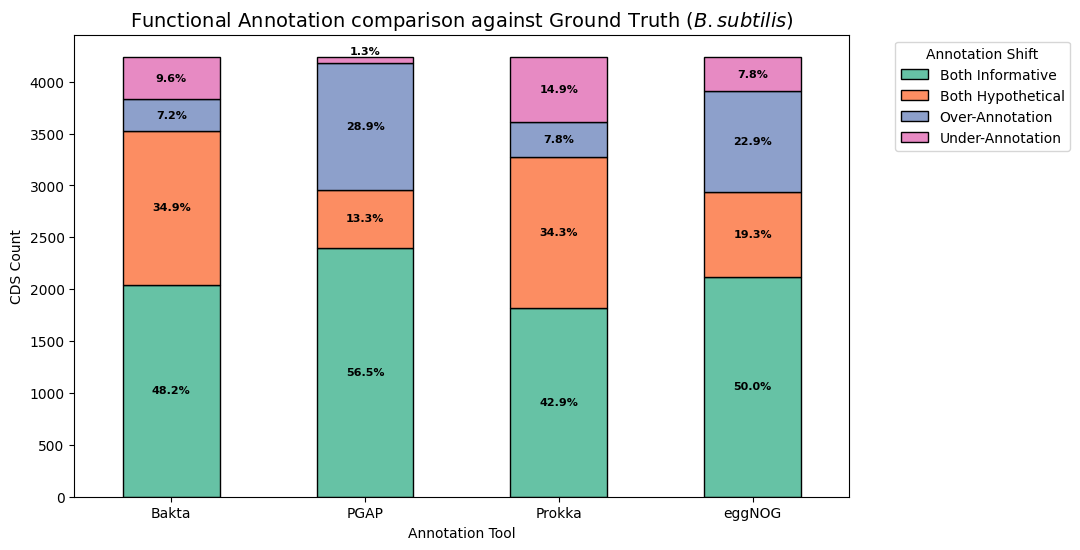


  Evaluating Functional Data: E. coli



Category,Both Informative,Both Hypothetical,Over-Annotation,Under-Annotation
Tool,,,,
Bakta,2947,567,425,401
PGAP,3126,239,753,222
Prokka,2622,661,331,726
eggNOG,2934,345,647,414


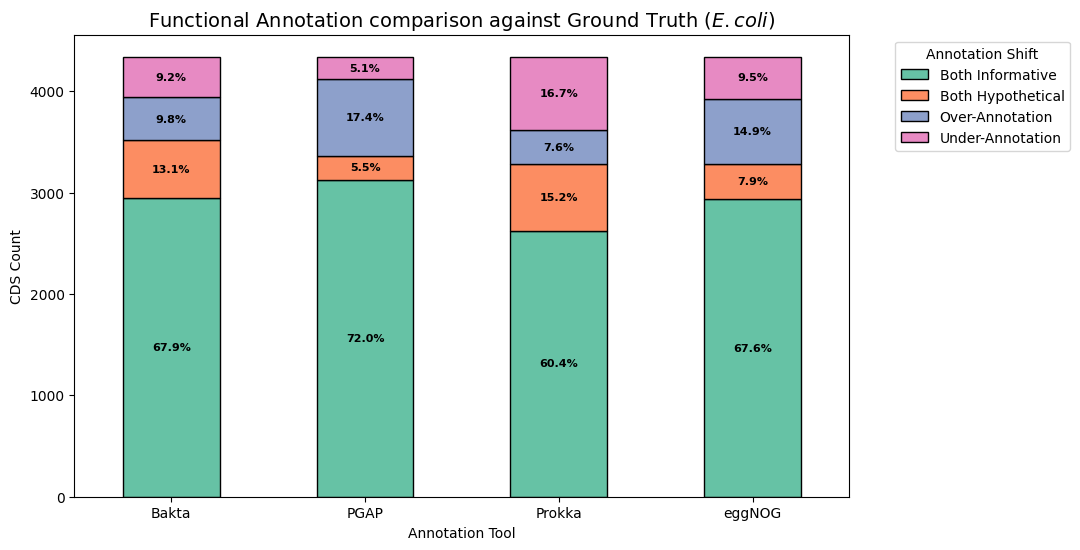

In [2]:
# Cell 2: Functional Analysis Loop
for org_id, org_name in ORGANISMS.items():
    print("\n=========================================")
    print(f"  Evaluating Functional Data: {org_name}")
    print("=========================================\n")
    
    input_csv = f"{org_id}_data/{org_id}_concordant_CDS.csv"
    if not os.path.exists(input_csv):
        print(f"Skipping {org_name} - {input_csv} not found.")
        continue
        
    df_func = pd.read_csv(input_csv)
    
    
    summary_table = categorize_functional_shifts(df_func, tools=TOOLS_TO_EVALUATE)
    display(summary_table)
    

    ax = summary_table.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6), 
        color=[COLOR_MAP[cat] for cat in summary_table.columns], 
        edgecolor='black'
    )
    
    plt.title(f"Functional Annotation comparison against Ground Truth ($\\mathit{{{org_name}}}$)", fontsize=14)
    plt.ylabel("CDS Count")
    plt.xlabel("Annotation Tool")
    plt.xticks(rotation=0)
    plt.legend(title="Annotation Shift", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    total = summary_table.sum(axis=1).iloc[0]
    
    # Your custom label logic
    for idx, container in enumerate(ax.containers):
        labels = [f'{v/total*100:.1f}%' if v > 0 else '' for v in container.datavalues]
        text_objs = ax.bar_label(container, labels=labels, label_type='center', fontsize=8, fontweight='bold')
        # do the tweak only if it's bacillus
        if org_id == "bacillus":
            if idx == 3 and len(text_objs) > 1:
                try:
                    text_objs[1].set_y(text_objs[1].get_position()[1] + 6)
                except IndexError:
                    pass
                    
    save_path = f"{org_id}_data/{org_id}_functional_summary.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=600)
    plt.show()